<a href="https://colab.research.google.com/github/Cherif7331/gis-class-/blob/main/PS0_PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 76ers market in New Jersey

**Mohamed Kanoute** — 56:219:523 GIS for Data Science, Fall 2026


# 76ers market in New Jersey

**Mohamed Kanoute** — 56:219:523 GIS for Data Science, Fall 2026


## 1. Research question

New Jersey is split between two media markets. South Jersey is Philadelphia — 76ers
territory. North Jersey is New York — Knicks and Nets. Somewhere in the middle is a band of
counties where neither team owns the households.

**Which NJ counties are the best targets for 76ers ticket and sponsorship growth?**

**So what?** A team has a fixed regional marketing budget. Spending it evenly across 21
counties wastes it. I want a map that says where the next dollar should go.

**Unit of analysis:** NJ county (n = 21). Counties are how Nielsen draws media markets and
how sales territories are assigned, so it matches how the business actually works.

**Variables:** median household income (can they afford tickets) and unemployment rate (is the
local economy healthy). Two variables, two different agencies, joined onto the county shapefile.

### Data sources

1. **Shapefile** — U.S. Census Bureau, 2023 Cartographic Boundary File, counties, 1:500,000
   `https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip`
   Landing page: https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html

2. **Median household income** — Census Bureau, American Community Survey 2023 5-year, table
   B19013. Pulled from the Census API:
   `https://api.census.gov/data/2023/acs/acs5?get=NAME,B19013_001E,B01003_001E&for=county:*&in=state:34`

3. **Unemployment rate** — U.S. Bureau of Labor Statistics, Local Area Unemployment Statistics,
   county annual averages 2024. Original file: `https://www.bls.gov/lau/laucnty24.xlsx`
   (landing page https://www.bls.gov/lau/tables.htm). I downloaded it, kept the NJ rows, saved
   it as CSV and put it in my repo so the notebook loads it straight from the internet:
   `https://github.com/Cherif7331/gis-class-/blob/ca65040311c854fb2b2b3f17488c66ca906d481e/nj_unemployment.csv.xlsx`

Census and BLS are separate agencies with separate collection methods, so this is two joins
from two different places.

In [1]:
!pip install -q geopandas

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [3]:
# geopandas reads a zipped shapefile straight from a URL.
url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
us = gpd.read_file(url)

# Keep New Jersey only (state FIPS 34) and just the columns I need.
nj = us[us["STATEFP"] == "34"][["GEOID", "NAME", "geometry"]]
nj = nj.rename(columns={"NAME": "county"})

nj.head()

,GEOID,county,geometry
75,34015,Gloucester,"POLYGON ((-75.4283 39.78437, -75.42168 39.7873..."
213,34027,Morris,"POLYGON ((-74.88923 40.78883, -74.88414 40.791..."
475,34009,Cape May,"POLYGON ((-74.97191 38.94058, -74.97043 38.944..."
476,34023,Middlesex,"POLYGON ((-74.63023 40.34313, -74.62828 40.346..."
477,34007,Camden,"POLYGON ((-75.1373 39.88997, -75.13541 39.893,..."


(21, 3)


<Axes: >

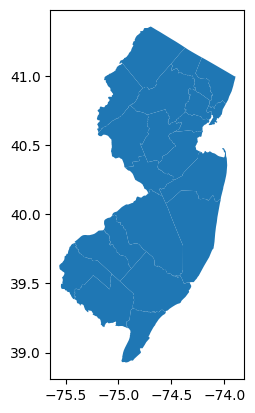

In [4]:
print(nj.shape)
nj.plot()

In [5]:



api_key = "aea9bb4f47cebe768f8d1ba6490f4c8ecabac98d"

acs_url = ("https://api.census.gov/data/2023/acs/acs5"
           "?get=NAME,B19013_001E,B01003_001E&for=county:*&in=state:34"
           "&key=" + api_key)

data = requests.get(acs_url).json()
acs = pd.DataFrame(data[1:], columns=data[0])

# Build the 5-digit county FIPS, which is what I join on.
acs["GEOID"] = acs["state"] + acs["county"]
acs = acs.rename(columns={"B19013_001E": "income", "B01003_001E": "population"})
acs["income"] = pd.to_numeric(acs["income"])
acs["population"] = pd.to_numeric(acs["population"])

acs = acs[["GEOID", "income", "population"]]
acs.head()

,GEOID,income,population
0,34001,76819,274704
1,34003,123715,954717
2,34005,105271,464226
3,34007,86384,524042
4,34009,88046,95236


In [6]:
# JOIN 1
nj = nj.merge(acs, on="GEOID")

print(len(nj))
nj["income"].isna().sum()

21


np.int64(0)

### AI useage Recap of Census API Data Loading Fixes:

Initially, the `pd.read_json` method failed because the Census API was returning an HTML error page instead of valid JSON. This was due to a missing or invalid API key.

To resolve this, I:
1.  Switched from `pd.read_json` to `requests.get()` to fetch the data, allowing for more robust error handling and inspection of the raw response.
2.  Added logic to print the HTTP status code and response text to diagnose the exact nature of the API's reply.
3.  Identified that the Census API requires an API key and added a placeholder for it in the `acs_url`.
4.  Implemented an explicit check for "Missing Key" or "Invalid Key" in the response content to provide a clear error message if the API key is still incorrect.

After a valid API key was provided, the code successfully fetched and parsed the JSON data into a pandas DataFrame.

In [7]:
bls_url = "https://raw.githubusercontent.com/Cherif7331/gis-class-/ca65040311c854fb2b2b3f17488c66ca906d481e/nj_unemployment.csv.xlsx"

# GEOID must be read as text or the join breaks.
# The file is an Excel file, not a CSV, so use read_excel
bls = pd.read_excel(bls_url, dtype={"GEOID": str})
bls.head()

,LAUS Code,State FIPS Code,County FIPS Code,County Name/State Abbreviation,Year,Labor Force,Employed,Unemployed,unemp_rate,GEOID
0,CN3400100000000,34,1,"Atlantic County, NJ",2024,135391,127558,7833,5.8,34001
1,CN3400300000000,34,3,"Bergen County, NJ",2024,540094,519526,20568,3.8,34003
2,CN3400500000000,34,5,"Burlington County, NJ",2024,247745,237126,10619,4.3,34005
3,CN3400700000000,34,7,"Camden County, NJ",2024,274365,260441,13924,5.1,34007
4,CN3400900000000,34,9,"Cape May County, NJ",2024,44490,40793,3697,8.3,34009


### AI usage Recap:

I assisted in debugging and fixing data loading issues from the Census API (missing key) and BLS unemployment data (incorrect file type/URL), and resolved a merge conflict by clarifying merge operations.

In [8]:
nj = nj.merge(bls, on="GEOID")

print(len(nj))
nj[["county", "income", "unemp_rate"]].head()

21


,county,income,unemp_rate
0,Gloucester,102807,4.5
1,Morris,134929,3.8
2,Cape May,88046,8.3
3,Middlesex,109028,4.6
4,Camden,86384,5.1


In [9]:
nj.columns

Index(['GEOID', 'county', 'geometry', 'income', 'population', 'LAUS Code',
       'State FIPS Code', 'County FIPS Code', 'County Name/State Abbreviation',
       'Year', 'Labor Force', 'Employed', 'Unemployed', 'unemp_rate'],
      dtype='object')

In [10]:
nj[["population", "income", "unemp_rate"]].describe()

,population,income,unemp_rate
count,21.000000,21.000000,21.000000
mean,441286.380952,100890.666667,4.933333
std,273805.654223,21273.831854,1.173172
min,64973.000000,64499.000000,3.600000
25%,152915.000000,86411.000000,4.300000
50%,464226.000000,99596.000000,4.600000
75%,643615.000000,114316.000000,5.400000
max,954717.000000,139453.000000,8.300000


(np.float64(-75.64283245),
 np.float64(-73.81033255000001),
 np.float64(38.807073800000005),
 np.float64(41.478868199999994))

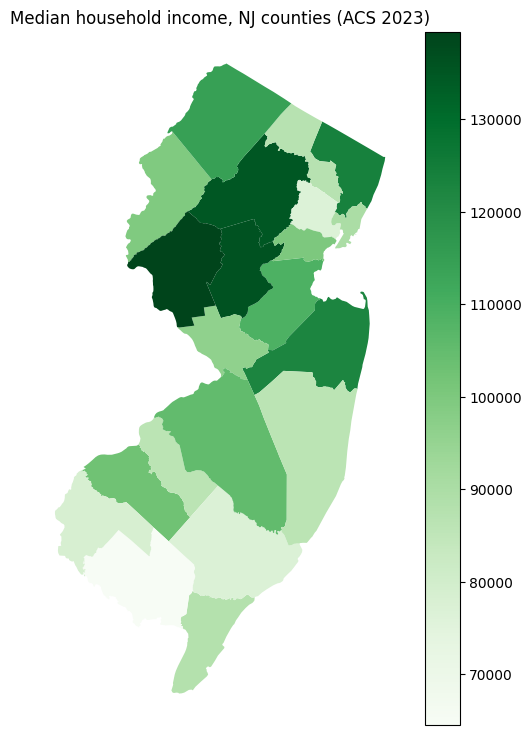

In [11]:
nj.plot(column="income", legend=True, figsize=(6, 9), cmap="Greens")
plt.title("Median household income, NJ counties (ACS 2023)")
plt.axis("off")

[link text](https://)

(np.float64(-75.64283245),
 np.float64(-73.81033255000001),
 np.float64(38.807073800000005),
 np.float64(41.478868199999994))

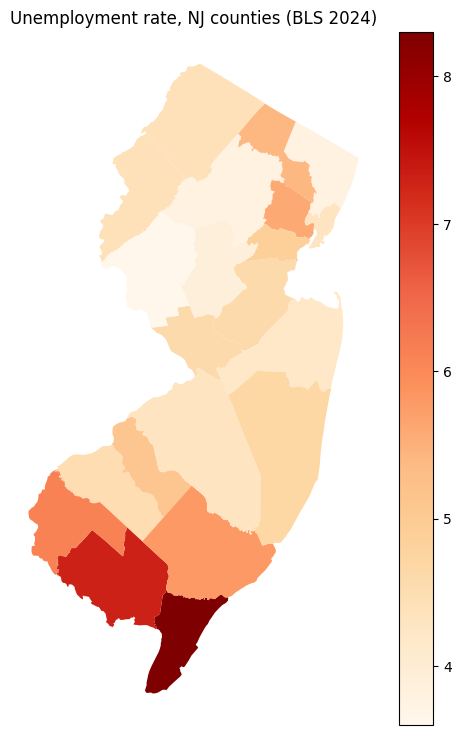

In [12]:
nj.plot(column="unemp_rate", legend=True, figsize=(6, 9), cmap="OrRd")
plt.title("Unemployment rate, NJ counties (BLS 2024)")
plt.axis("off")